In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip uninstall -y mediapipe
!pip install -q opencv-python-headless mediapipe==0.10.21 tqdm scikit-learn matplotlib

Found existing installation: mediapipe 0.10.21
Uninstalling mediapipe-0.10.21:
  Successfully uninstalled mediapipe-0.10.21


In [3]:
import os
import cv2
import json
import random
import numpy as np
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import mediapipe as mp

In [23]:
# =========================
# CONFIGURATION
# =========================

# FaceForensics++ dataset location in Google Drive
DATASET_ROOT = Path("/content/drive/MyDrive/FaceForensics++_C23")

# Use only these folders for Version 2
REAL_VIDEO_DIR = DATASET_ROOT / "original"
FAKE_VIDEO_DIR = DATASET_ROOT / "Deepfakes"

# Version 2 output locations
PROJECT_ROOT = Path("/content/drive/MyDrive/deepfake_project")
OUTPUT_ROOT_V2 = PROJECT_ROOT / "data"
PROCESSED_ROOT_V2 = OUTPUT_ROOT_V2 / "processed_v2"
METADATA_ROOT_V2 = OUTPUT_ROOT_V2 / "metadata_v2"

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Frame extraction settings
FRAME_INTERVAL = 25
MAX_FRAMES_PER_VIDEO = 8
IMG_SIZE = (224, 224)

# Face detection settings
MIN_DETECTION_CONFIDENCE = 0.5
FACE_PADDING = 0.25  # extra padding around detected face box

# Optional limits for quick trial runs
# Set to None for full dataset
MAX_REAL_VIDEOS = None
MAX_FAKE_VIDEOS = None

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("DATASET_ROOT:", DATASET_ROOT)
print("REAL_VIDEO_DIR:", REAL_VIDEO_DIR)
print("FAKE_VIDEO_DIR:", FAKE_VIDEO_DIR)
print("PROCESSED_ROOT_V2:", PROCESSED_ROOT_V2)
print("METADATA_ROOT_V2:", METADATA_ROOT_V2)

DATASET_ROOT: /content/drive/MyDrive/FaceForensics++_C23
REAL_VIDEO_DIR: /content/drive/MyDrive/FaceForensics++_C23/original
FAKE_VIDEO_DIR: /content/drive/MyDrive/FaceForensics++_C23/Deepfakes
PROCESSED_ROOT_V2: /content/drive/MyDrive/deepfake_project/data/processed_v2
METADATA_ROOT_V2: /content/drive/MyDrive/deepfake_project/data/metadata_v2


In [5]:
print("Dataset root exists:", DATASET_ROOT.exists())
print("Real folder exists:", REAL_VIDEO_DIR.exists())
print("Fake folder exists:", FAKE_VIDEO_DIR.exists())

if DATASET_ROOT.exists():
    print("\nTop-level contents of dataset root:")
    for item in sorted(DATASET_ROOT.iterdir()):
        print("-", item.name)

Dataset root exists: True
Real folder exists: True
Fake folder exists: True

Top-level contents of dataset root:
- DeepFakeDetection
- Deepfakes
- Face2Face
- FaceShifter
- FaceSwap
- NeuralTextures
- csv
- original


In [6]:
def make_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

for split in ["train", "val", "test"]:
    for cls in ["real", "fake"]:
        make_dir(PROCESSED_ROOT_V2 / split / cls)

make_dir(METADATA_ROOT_V2)

print("Version 2 output folders created.")

Version 2 output folders created.


In [7]:
def clear_image_files(folder: Path):
    if folder.exists():
        for f in folder.iterdir():
            if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                f.unlink()

def list_video_files(folder: Path):
    valid_exts = {".mp4", ".avi", ".mov", ".mkv"}
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in valid_exts])

def count_images(folder: Path):
    valid_exts = {".jpg", ".jpeg", ".png"}
    return len([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_exts])

def split_videos(video_list, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"

    train_videos, temp_videos = train_test_split(
        video_list,
        test_size=(1 - train_ratio),
        random_state=seed,
        shuffle=True
    )

    relative_test_ratio = test_ratio / (val_ratio + test_ratio)

    val_videos, test_videos = train_test_split(
        temp_videos,
        test_size=relative_test_ratio,
        random_state=seed,
        shuffle=True
    )

    return train_videos, val_videos, test_videos

In [24]:
real_videos = list_video_files(REAL_VIDEO_DIR)
fake_videos = list_video_files(FAKE_VIDEO_DIR)

if MAX_REAL_VIDEOS is not None:
    real_videos = real_videos[:MAX_REAL_VIDEOS]

if MAX_FAKE_VIDEOS is not None:
    fake_videos = fake_videos[:MAX_FAKE_VIDEOS]

print(f"Found {len(real_videos)} real videos")
print(f"Found {len(fake_videos)} fake videos")

print("\nSample real videos:")
for p in real_videos[:5]:
    print(" ", p)

print("\nSample fake videos:")
for p in fake_videos[:5]:
    print(" ", p)

Found 1000 real videos
Found 1000 fake videos

Sample real videos:
  /content/drive/MyDrive/FaceForensics++_C23/original/000.mp4
  /content/drive/MyDrive/FaceForensics++_C23/original/001.mp4
  /content/drive/MyDrive/FaceForensics++_C23/original/002.mp4
  /content/drive/MyDrive/FaceForensics++_C23/original/003.mp4
  /content/drive/MyDrive/FaceForensics++_C23/original/004.mp4

Sample fake videos:
  /content/drive/MyDrive/FaceForensics++_C23/Deepfakes/000_003.mp4
  /content/drive/MyDrive/FaceForensics++_C23/Deepfakes/001_870.mp4
  /content/drive/MyDrive/FaceForensics++_C23/Deepfakes/002_006.mp4
  /content/drive/MyDrive/FaceForensics++_C23/Deepfakes/003_000.mp4
  /content/drive/MyDrive/FaceForensics++_C23/Deepfakes/004_982.mp4


In [25]:
real_train_videos, real_val_videos, real_test_videos = split_videos(
    real_videos,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=RANDOM_SEED
)

fake_train_videos, fake_val_videos, fake_test_videos = split_videos(
    fake_videos,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=RANDOM_SEED
)

print("REAL video split:")
print(" train:", len(real_train_videos))
print(" val  :", len(real_val_videos))
print(" test :", len(real_test_videos))

print("\nFAKE video split:")
print(" train:", len(fake_train_videos))
print(" val  :", len(fake_val_videos))
print(" test :", len(fake_test_videos))

REAL video split:
 train: 699
 val  : 150
 test : 151

FAKE video split:
 train: 699
 val  : 150
 test : 151


In [26]:
split_metadata_v2 = {
    "config": {
        "dataset_root": str(DATASET_ROOT),
        "real_video_dir": str(REAL_VIDEO_DIR),
        "fake_video_dir": str(FAKE_VIDEO_DIR),
        "processed_root_v2": str(PROCESSED_ROOT_V2),
        "train_ratio": TRAIN_RATIO,
        "val_ratio": VAL_RATIO,
        "test_ratio": TEST_RATIO,
        "frame_interval": FRAME_INTERVAL,
        "max_frames_per_video": MAX_FRAMES_PER_VIDEO,
        "img_size": IMG_SIZE,
        "min_detection_confidence": MIN_DETECTION_CONFIDENCE,
        "face_padding": FACE_PADDING,
        "random_seed": RANDOM_SEED
    },
    "real_train_videos": [str(p) for p in real_train_videos],
    "real_val_videos": [str(p) for p in real_val_videos],
    "real_test_videos": [str(p) for p in real_test_videos],
    "fake_train_videos": [str(p) for p in fake_train_videos],
    "fake_val_videos": [str(p) for p in fake_val_videos],
    "fake_test_videos": [str(p) for p in fake_test_videos],
}

split_metadata_path_v2 = METADATA_ROOT_V2 / "video_split_metadata_v2.json"

with open(split_metadata_path_v2, "w") as f:
    json.dump(split_metadata_v2, f, indent=2)

print("Saved V2 split metadata to:", split_metadata_path_v2)

Saved V2 split metadata to: /content/drive/MyDrive/deepfake_project/data/metadata_v2/video_split_metadata_v2.json


In [27]:
for split in ["train", "val", "test"]:
    for cls in ["real", "fake"]:
        clear_image_files(PROCESSED_ROOT_V2 / split / cls)

print("Old V2 extracted images cleared.")

Old V2 extracted images cleared.


In [12]:
mp_face_detection = mp.solutions.face_detection

In [13]:
def clamp(value, min_value, max_value):
    return max(min_value, min(value, max_value))

def extract_largest_face_crop(frame_bgr, face_detector, face_padding=0.25):
    """
    Detects faces using MediaPipe and returns the cropped largest face region.
    Returns None if no face is detected.
    """
    h, w = frame_bgr.shape[:2]
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    results = face_detector.process(frame_rgb)
    if not results.detections:
        return None

    best_crop = None
    best_area = 0

    for detection in results.detections:
        bbox = detection.location_data.relative_bounding_box

        x_min = bbox.xmin * w
        y_min = bbox.ymin * h
        box_w = bbox.width * w
        box_h = bbox.height * h

        # Add padding
        pad_w = box_w * face_padding
        pad_h = box_h * face_padding

        x1 = int(clamp(x_min - pad_w, 0, w - 1))
        y1 = int(clamp(y_min - pad_h, 0, h - 1))
        x2 = int(clamp(x_min + box_w + pad_w, 0, w - 1))
        y2 = int(clamp(y_min + box_h + pad_h, 0, h - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        area = (x2 - x1) * (y2 - y1)
        if area > best_area:
            best_area = area
            best_crop = frame_bgr[y1:y2, x1:x2]

    return best_crop

def preprocess_face_crop(face_crop_bgr, img_size=(224, 224)):
    resized = cv2.resize(face_crop_bgr, img_size)
    return resized

In [14]:
def extract_faces_from_video(
    video_path: Path,
    output_dir: Path,
    label_prefix: str,
    face_detector,
    frame_interval: int = 25,
    max_frames_per_video: int = 8,
    img_size=(224, 224),
    face_padding=0.25
):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {
            "faces_saved": 0,
            "frames_examined": 0,
            "frames_sampled": 0,
            "frames_no_face": 0,
            "video_failed": True
        }

    saved_count = 0
    frame_idx = 0
    frames_examined = 0
    frames_sampled = 0
    frames_no_face = 0
    video_stem = video_path.stem.replace(" ", "_")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frames_examined += 1

        if frame_idx % frame_interval == 0:
            frames_sampled += 1

            face_crop = extract_largest_face_crop(
                frame_bgr=frame,
                face_detector=face_detector,
                face_padding=face_padding
            )

            if face_crop is None:
                frames_no_face += 1
            else:
                processed = preprocess_face_crop(face_crop, img_size=img_size)
                filename = f"{label_prefix}_{video_stem}_f{frame_idx:05d}.jpg"
                out_path = output_dir / filename

                success = cv2.imwrite(str(out_path), processed)
                if success:
                    saved_count += 1

                if saved_count >= max_frames_per_video:
                    break

        frame_idx += 1

    cap.release()

    return {
        "faces_saved": saved_count,
        "frames_examined": frames_examined,
        "frames_sampled": frames_sampled,
        "frames_no_face": frames_no_face,
        "video_failed": False
    }

In [15]:
def extract_split_v2(videos, output_dir, label_prefix, split_name):
    total_faces_saved = 0
    total_frames_examined = 0
    total_frames_sampled = 0
    total_frames_no_face = 0
    used_videos = 0
    failed_videos = []

    with mp_face_detection.FaceDetection(
        model_selection=1,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE
    ) as face_detector:

        for video_path in tqdm(videos, desc=f"Extracting V2 {split_name}/{label_prefix}"):
            stats = extract_faces_from_video(
                video_path=video_path,
                output_dir=output_dir,
                label_prefix=label_prefix,
                face_detector=face_detector,
                frame_interval=FRAME_INTERVAL,
                max_frames_per_video=MAX_FRAMES_PER_VIDEO,
                img_size=IMG_SIZE,
                face_padding=FACE_PADDING
            )

            total_faces_saved += stats["faces_saved"]
            total_frames_examined += stats["frames_examined"]
            total_frames_sampled += stats["frames_sampled"]
            total_frames_no_face += stats["frames_no_face"]

            if stats["video_failed"]:
                failed_videos.append(str(video_path))
            elif stats["faces_saved"] > 0:
                used_videos += 1

    summary = {
        "split": split_name,
        "class": label_prefix,
        "videos_input": len(videos),
        "videos_used": used_videos,
        "faces_saved": total_faces_saved,
        "frames_examined": total_frames_examined,
        "frames_sampled": total_frames_sampled,
        "frames_no_face": total_frames_no_face,
        "failed_videos": failed_videos
    }

    return summary

In [28]:
train_real_summary_v2 = extract_split_v2(
    real_train_videos,
    PROCESSED_ROOT_V2 / "train" / "real",
    "real",
    "train"
)

train_fake_summary_v2 = extract_split_v2(
    fake_train_videos,
    PROCESSED_ROOT_V2 / "train" / "fake",
    "fake",
    "train"
)

print(train_real_summary_v2)
print(train_fake_summary_v2)

Extracting V2 train/fake: 100%|██████████| 699/699 [32:55<00:00,  2.83s/it]

{'split': 'train', 'class': 'real', 'videos_input': 699, 'videos_used': 699, 'faces_saved': 5592, 'frames_examined': 123124, 'frames_sampled': 5596, 'frames_no_face': 4, 'failed_videos': []}
{'split': 'train', 'class': 'fake', 'videos_input': 699, 'videos_used': 699, 'faces_saved': 5592, 'frames_examined': 123249, 'frames_sampled': 5601, 'frames_no_face': 9, 'failed_videos': []}


In [29]:
val_real_summary_v2 = extract_split_v2(
    real_val_videos,
    PROCESSED_ROOT_V2 / "val" / "real",
    "real",
    "val"
)

val_fake_summary_v2 = extract_split_v2(
    fake_val_videos,
    PROCESSED_ROOT_V2 / "val" / "fake",
    "fake",
    "val"
)

print(val_real_summary_v2)
print(val_fake_summary_v2)

Extracting V2 val/fake: 100%|██████████| 150/150 [06:58<00:00,  2.79s/it]

{'split': 'val', 'class': 'real', 'videos_input': 150, 'videos_used': 150, 'faces_saved': 1200, 'frames_examined': 26400, 'frames_sampled': 1200, 'frames_no_face': 0, 'failed_videos': []}
{'split': 'val', 'class': 'fake', 'videos_input': 150, 'videos_used': 150, 'faces_saved': 1200, 'frames_examined': 26425, 'frames_sampled': 1201, 'frames_no_face': 1, 'failed_videos': []}


In [30]:
test_real_summary_v2 = extract_split_v2(
    real_test_videos,
    PROCESSED_ROOT_V2 / "test" / "real",
    "real",
    "test"
)

test_fake_summary_v2 = extract_split_v2(
    fake_test_videos,
    PROCESSED_ROOT_V2 / "test" / "fake",
    "fake",
    "test"
)

print(test_real_summary_v2)
print(test_fake_summary_v2)

Extracting V2 test/fake: 100%|██████████| 151/151 [07:02<00:00,  2.80s/it]

{'split': 'test', 'class': 'real', 'videos_input': 151, 'videos_used': 151, 'faces_saved': 1208, 'frames_examined': 26576, 'frames_sampled': 1208, 'frames_no_face': 0, 'failed_videos': []}
{'split': 'test', 'class': 'fake', 'videos_input': 151, 'videos_used': 151, 'faces_saved': 1208, 'frames_examined': 26576, 'frames_sampled': 1208, 'frames_no_face': 0, 'failed_videos': []}


In [31]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["real", "fake"]:
        folder = PROCESSED_ROOT_V2 / split / cls
        print(f"  {cls}: {count_images(folder)}")


TRAIN
  real: 5592
  fake: 5592

VAL
  real: 1200
  fake: 1200

TEST
  real: 1208
  fake: 1208


In [32]:
extraction_summary_v2 = {
    "train_real": train_real_summary_v2,
    "train_fake": train_fake_summary_v2,
    "val_real": val_real_summary_v2,
    "val_fake": val_fake_summary_v2,
    "test_real": test_real_summary_v2,
    "test_fake": test_fake_summary_v2,
}

extraction_summary_path_v2 = METADATA_ROOT_V2 / "extraction_summary_v2.json"

with open(extraction_summary_path_v2, "w") as f:
    json.dump(extraction_summary_v2, f, indent=2)

print("Saved V2 extraction summary to:", extraction_summary_path_v2)

Saved V2 extraction summary to: /content/drive/MyDrive/deepfake_project/data/metadata_v2/extraction_summary_v2.json


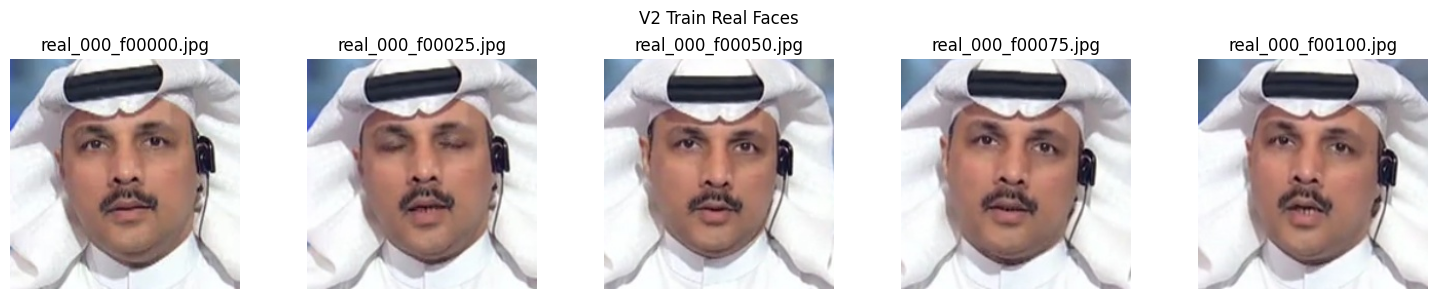

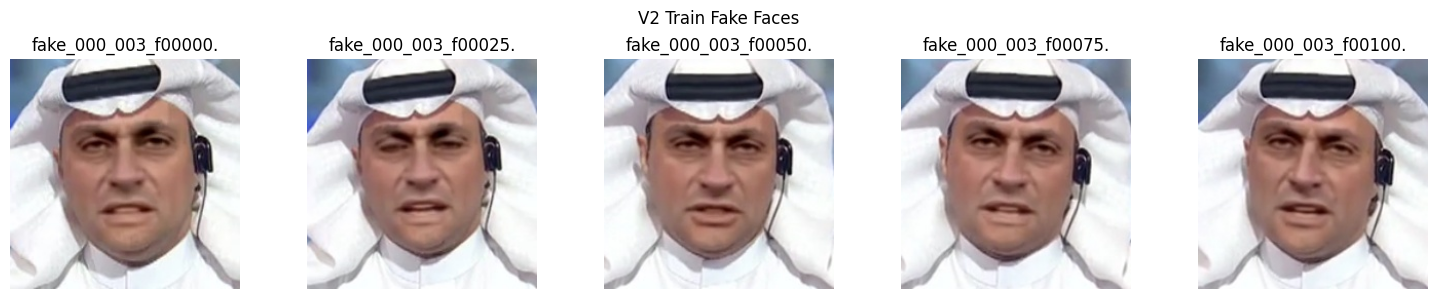

In [33]:
def show_sample_images(folder, n=5, title=None):
    image_paths = sorted(list(folder.glob("*.jpg")))[:n]

    if len(image_paths) == 0:
        print(f"No images found in {folder}")
        return

    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(image_paths):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(image_paths), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name[:20])

    if title:
        plt.suptitle(title)

    plt.tight_layout()
    plt.show()

show_sample_images(PROCESSED_ROOT_V2 / "train" / "real", n=5, title="V2 Train Real Faces")
show_sample_images(PROCESSED_ROOT_V2 / "train" / "fake", n=5, title="V2 Train Fake Faces")

In [34]:
print("Processed V2 dataset root:", PROCESSED_ROOT_V2)

for split in ["train", "val", "test"]:
    split_path = PROCESSED_ROOT_V2 / split
    print(f"\n{split_path}")
    for cls in ["real", "fake"]:
        cls_path = split_path / cls
        print(f"  {cls_path} -> exists: {cls_path.exists()}, images: {count_images(cls_path)}")

Processed V2 dataset root: /content/drive/MyDrive/deepfake_project/data/processed_v2

/content/drive/MyDrive/deepfake_project/data/processed_v2/train
  /content/drive/MyDrive/deepfake_project/data/processed_v2/train/real -> exists: True, images: 5592
  /content/drive/MyDrive/deepfake_project/data/processed_v2/train/fake -> exists: True, images: 5592

/content/drive/MyDrive/deepfake_project/data/processed_v2/val
  /content/drive/MyDrive/deepfake_project/data/processed_v2/val/real -> exists: True, images: 1200
  /content/drive/MyDrive/deepfake_project/data/processed_v2/val/fake -> exists: True, images: 1200

/content/drive/MyDrive/deepfake_project/data/processed_v2/test
  /content/drive/MyDrive/deepfake_project/data/processed_v2/test/real -> exists: True, images: 1208
  /content/drive/MyDrive/deepfake_project/data/processed_v2/test/fake -> exists: True, images: 1208
